In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils import plot_style, norm01; plot_style('notebook');

### Objective
Figure out what objective makes segmentation optimal.

In [32]:
def create_event_templates(n_events, n_dims, template_sd, rng):
    event_templates = []
    while len(event_templates) < n_events:  event_templates.append(rng.normal(len(event_templates)**2, template_sd, n_dims))
    return np.array(event_templates)

def populate_event(event_template, event_length, drift, rng):
    scenes = np.zeros((event_length, event_template.size))
    scenes[0] = event_template
    for t in range(1, event_length): scenes[t] = scenes[t-1] + rng.normal(0, drift, event_template.size)
    return scenes

def make_stimulus(n_events=6, n_dims=8, template_sd=0, min_len=6, max_len=14, drift=.5, seed=0):
    rng = np.random.default_rng(seed)

    true_event_ids = np.arange(n_events)
    true_event_templates = create_event_templates(n_events, n_dims, template_sd, rng)
    true_event_lengths   = rng.integers(min_len, max_len + 1, n_events)
    true_event_bounds = np.cumsum(true_event_lengths)[:-1]
    true_events_list = [populate_event(true_event_templates[e], true_event_lengths[e], drift, rng) for e in range(n_events)]
    true_events = np.vstack(true_events_list)  # (T, n_dims)

    stim_event_ids = rng.permutation(n_events)
    stim_event_templates = true_event_templates[stim_event_ids]
    stim_event_lengths = true_event_lengths[stim_event_ids]
    stim_event_bounds = np.cumsum(stim_event_lengths)[:-1] if stim_event_lengths.size > 0 else np.array([])
    stim_events = np.vstack([true_events_list[e] for e in stim_event_ids])

    return true_event_ids, true_event_templates, true_event_lengths, true_event_bounds, true_events, stim_event_ids, stim_event_templates, stim_event_lengths, stim_event_bounds, stim_events

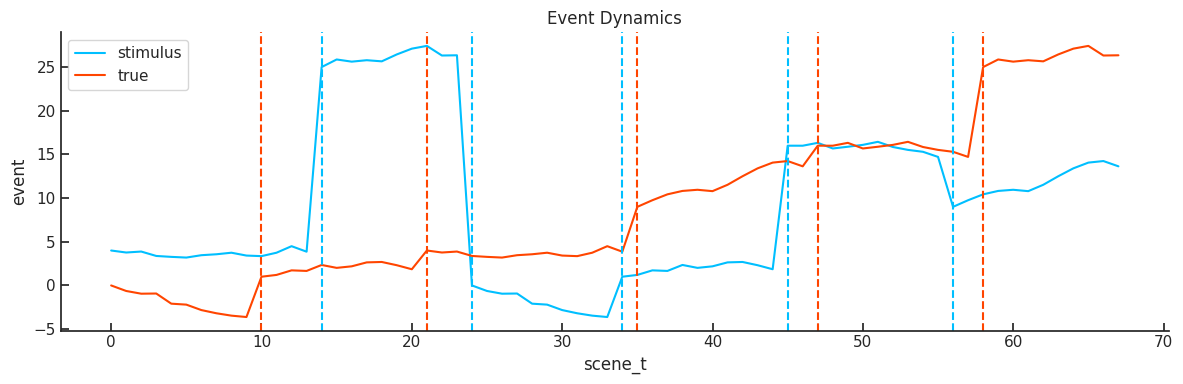

In [33]:
true_event_ids, true_event_templates, true_event_lengths, true_event_bounds, true_events, stim_event_ids, stim_event_templates, stim_event_lengths, stim_event_bounds, stim_events = make_stimulus(seed=0,n_dims=1)

plt.figure(figsize=(12, 4)); plt.title("Event Dynamics")
for stim_dim in range(stim_events.shape[1]): plt.plot(stim_events[:, stim_dim], c='deepskyblue',label='stimulus')
for stim_dim in range(true_events.shape[1]):   plt.plot(true_events[:, stim_dim],   c='orangered', label='true')
for bound in stim_event_bounds: plt.axvline(bound, ls="--", c='deepskyblue')
for bound in true_event_bounds: plt.axvline(bound, ls="--", c='orangered')
plt.xlabel("scene_t"); plt.ylabel("event"); plt.legend(); plt.tight_layout(); plt.show()